# Discovering a linear causal signaling network from perturbation data

Perturbation experiments often measure continuous molecular responses: log-fold changes in phosphoproteins, reporter intensities, or expression signatures after stimulating or inhibiting a pathway component.

This guide starts from one question:

> **Which directed interactions from a prior-knowledge network produce a linear model that fits the measured responses across observational and intervention conditions?**

`LinearDAGDiscovery` selects a subset of edges from a directed prior-knowledge network (PKN), requires the selected graph to contain no directed cycles, and fits one linear equation for each measured vertex. Each selected edge has one coefficient that is shared across all samples. A hard intervention removes the equation for its target in that sample; a shift intervention keeps the equation and adds a known or fitted offset.

As many other methods implemented in CORNETO, the optimization uses auxiliary flow variables for connectivity. Every selected edge must belong to at least one directed route from an intervened vertex to a measured response. These variables enforce connectivity only; they are not biochemical fluxes, effect sizes, or confidence scores.

CORNETO calls each row in `Data` a **sample**. A sample may be one bulk experimental condition or one cell. The intervention metadata is attached to the measured target within each sample, as shown below.

## When is this method useful?

| Experimental setting | Interpretation |
|---|---|
| Continuous molecular measurements | Values may be signed and need not be discretized |
| Several perturbation conditions | Perturbations help orient otherwise ambiguous associations |
| Directed PKN with alternatives or feedback | The method chooses a subset with no directed cycles |
| One linear relationship shared across samples | Each edge coefficient is the same in every sample or condition |

Use `CellNOptDAG` instead when you have a more mechanistic prior knowledge of a pathway from perturbations to readouts or phenotypes
and you want to use boolean logic.

## What CORNETO adds

Many causal-discovery methods are run on a dataset and return a DAG. CORNETO instead uses the graph as part of a model of the experiment. In `LinearDAGDiscovery`, the linear equations fit the measured responses, the PKN defines which biological interactions are possible, and the intervention annotations specify which equations are modified by the experiment. The result therefore contains both a network and a fitted explanation of the experimental data.

Prior knowledge does not have to stop at the initial PKN. Before solving, users can add assumptions such as requiring or forbidding an interaction, constraining its sign or coefficient, or limiting which mechanisms may be selected. The complete model is then fitted again under that hypothesis. Comparing the original and constrained models shows whether the hypothesis is compatible with the data, how much it changes held-out prediction, and which other interactions must change to accommodate it.

This modeling flexibility is the main reason to use CORNETO instead. The trade-off is computational cost: enforcing graph structure, interventions, prior knowledge, and additional constraints together requires mixed-integer optimization. It is worthwhile when these modeling choices are central to the analysis; if the goal is only to obtain a graph quickly, a more scalable causal-discovery method may be preferable.

## Example: separating the AKT and ERK branches downstream of EGFR

Consider a small perturbation panel measuring five signaling activities. The biological hypothesis is that EGFR activates both AKT and ERK, AKT inhibits FOXO, and ERK activates ELK1.

The PKN is intentionally less certain. It also contains reverse interactions and AKT–ERK cross-talk that could form cycles. The fit will show which of these candidate edges are selected under the chosen loss and penalties.

The values below are simulated, centered log-fold changes coming from the assumed linear signaling in every condition, with a small noise.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import corneto as cn
from corneto.data import Data
from corneto.methods import LinearDAGDiscovery

### Define the candidate biology

Interaction signs are stored in the PKN. When `enforce_signs=True`, an activating sign constrains the fitted coefficient to be nonnegative and an inhibitory sign constrains it to be nonpositive. The candidate graph contains several pairs of edges pointing in opposite directions; the selected graph, but not the PKN, is required to have no directed cycles.

In [2]:
pkn_edges = [
    ("EGFR", 1, "AKT"),
    ("EGFR", 1, "ERK"),
    ("AKT", -1, "FOXO"),
    ("ERK", 1, "ELK1"),
    ("AKT", 1, "EGFR"),
    ("ERK", 1, "EGFR"),
    ("FOXO", -1, "AKT"),
    ("ELK1", 1, "ERK"),
    ("AKT", 1, "ERK"),
    ("ERK", 1, "AKT"),
]
pkn = cn.Graph.from_tuples(pkn_edges)

pd.DataFrame(pkn_edges, columns=["source", "sign", "target"])

,source,sign,target
0,EGFR,1,AKT
1,EGFR,1,ERK
2,AKT,-1,FOXO
3,ERK,1,ELK1
4,AKT,1,EGFR
5,ERK,1,EGFR
6,FOXO,-1,AKT
7,ELK1,1,ERK
8,AKT,1,ERK
9,ERK,1,AKT


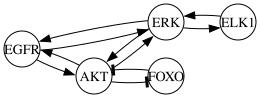

In [3]:
pkn.plot(graph_attr={"rankdir": "LR"})

### Define the perturbation experiment

Observational conditions vary EGFR without marking it as experimentally fixed. Intervention conditions mark EGFR, AKT, or ERK as a **hard intervention**. This means that the target is fixed to its supplied value: its own equation is omitted for that condition, while the fixed value can still be used in equations for downstream proteins.

One ELK1 measurement is missing. CORNETO will omit that response from the loss rather than replace it with zero.

In [4]:
rng = np.random.default_rng(13)
noise_sd = 0.08


def signaling_state(egfr, *, akt=None, erk=None):
    # Intervened values are fixed by the experiment; endogenous values include noise.
    akt = 1.1 * egfr + rng.normal(0, noise_sd) if akt is None else akt
    erk = 0.8 * egfr + rng.normal(0, noise_sd) if erk is None else erk
    return {
        "EGFR": egfr,
        "AKT": akt,
        "ERK": erk,
        "FOXO": -0.9 * akt + rng.normal(0, noise_sd),
        "ELK1": 1.2 * erk + rng.normal(0, noise_sd),
    }


conditions = [
    ("obs_1", signaling_state(-1.4), None),
    ("obs_2", signaling_state(-0.5), None),
    ("obs_3", signaling_state(0.7), None),
    ("obs_4", signaling_state(1.5), None),
    ("EGFR_low", signaling_state(-2.0), "EGFR"),
    ("EGFR_high", signaling_state(2.1), "EGFR"),
    ("AKT_on", signaling_state(-0.7, akt=1.8), "AKT"),
    ("AKT_off", signaling_state(1.0, akt=-1.5), "AKT"),
    ("ERK_on", signaling_state(-0.8, erk=1.7), "ERK"),
    ("ERK_off", signaling_state(0.6, erk=-1.6), "ERK"),
]

# Demonstrate a genuinely missing response.
conditions[6][1]["ELK1"] = None

experiment = pd.DataFrame(
    [values | {"intervention": target or "observational"} for _, values, target in conditions],
    index=[name for name, _, _ in conditions],
)
experiment.index.name = "condition"
experiment.round(3)

,EGFR,AKT,ERK,FOXO,ELK1,intervention
condition,,,,,,
obs_1,-1.4,-1.394,-1.366,1.331,-1.634,observational
obs_2,-0.5,-0.445,-0.369,0.546,-0.440,observational
obs_3,0.7,0.729,0.606,-0.621,0.699,observational
obs_4,1.5,1.630,1.258,-1.411,1.470,observational
EGFR_low,-2.0,-2.229,-1.745,2.141,-2.111,EGFR
EGFR_high,2.1,2.417,1.713,-2.020,2.179,EGFR
AKT_on,-0.7,1.800,-0.535,-1.502,NaN,AKT
AKT_off,1.0,-1.500,0.901,1.232,1.108,AKT
ERK_on,-0.8,-0.795,1.700,0.733,2.011,ERK


(linear-dag-intervention-metadata)=
### Mark interventions in `Data`

Each sample contains a feature for each measured PKN vertex. The feature's `value` is the measurement; its metadata tells `LinearDAGDiscovery` whether that vertex was directly intervened on in that sample. Put intervention metadata on the target feature only.

| Feature field | Expected value | When to use it |
|---|---|---|
| `mapping` | `"vertex"` | Required for a feature to represent a PKN vertex. |
| `value` | Numeric measurement | Required for an intervened target when fitting. |
| `intervention` | Omit for an observational feature; use `"hard"` or `"shift"` for an intervened target | `"hard"` removes the target's equation for that sample. `"shift"` keeps the equation and adds an offset. |
| `shift` | Numeric offset | Supply with `intervention="shift"` when the offset is known; otherwise omit it so the model estimates the offset. |
| `intervention_group` | A condition identifier shared by replicate samples | Optional for hard interventions; required when estimating a shift shared by replicates. It groups their connectivity evidence while each sample still contributes its own measurement to the fit. |

The `intervention` column in the table above names the target for display. In a `Data` feature, `intervention` instead names the intervention type. `intervened=True` is also accepted as an older spelling of `intervention="hard"`; use one form per feature. The example below uses `intervention="hard"`.

In [5]:
samples = {}
for condition, values, target in conditions:
    samples[condition] = {}
    for vertex, value in values.items():
        feature = {"mapping": "vertex", "value": value}
        if vertex == target:
            feature["intervention"] = "hard"
        samples[condition][vertex] = feature

data = Data.from_cdict(samples)

## Fit one linear DAG to all conditions

The objective adds `lambda_edges` for every selected edge, so the optimizer trades a lower fitting error against selecting fewer edges. `max_parents=2` imposes a literal graph constraint: no vertex may have more than two selected incoming edges. `enforce_signs=True` requires coefficients on PKN edges marked `+1` to be nonnegative and coefficients on edges marked `-1` to be nonpositive.

The default `coefficient_support="exact"` requires every selected edge to have a fitted coefficient whose normalized magnitude is at least `min_abs_coefficient=0.25`. This is a model choice about the smallest allowed coefficient, not a solver tolerance. With `coefficient_support="structural"`, an edge may be selected to complete an intervention-to-response route even when its regression coefficient is zero.

Standardized loss is enabled by default. For each target, CORNETO divides residuals by the standard deviation computed from training rows where the target is observed, is not hard-intervened, and has all candidate parents observed. This puts errors on a scale relative to that target's observed variation; it does not standardize the stored measurements or the fitted coefficients.

For this simulated dataset, `lambda_edges=0.1` yields the four generating edges. At `0.05`, the selected optimum also contains ERK → AKT with a raw coefficient near `0.03`. The penalty does not declare an edge biologically real or unreal; users should rerun plausible values and report which edges remain selected.

In [6]:
method = LinearDAGDiscovery(
    lambda_edges=0.1,
    coefficient_bound=3.0,
    fit_intercept=False,
    max_parents=2,
    enforce_signs=True,
    coefficient_support="exact",
    min_abs_coefficient=0.25,
)
problem = method.build(pkn, data)
result = problem.solve(solver="SCIPY")
result.status

'optimal'

## Which PKN edges were selected?

A fitted edge coefficient is the number multiplying the source value in the target's linear equation. Holding the other included parent values fixed, increasing the source by one measurement unit changes the model's predicted target by that coefficient. This is a model slope; interpreting it as a causal effect requires the assumptions discussed at the end of the guide.

Only the loss is standardized, so the displayed coefficients remain in the original source and target units. For thresholding, CORNETO rescales a coefficient as `coefficient × source_scale / target_scale`. In exact mode, a selected edge must have normalized magnitude at least `min_abs_coefficient`; every unselected edge has coefficient zero. This threshold can exclude weak but genuine relationships.

In [7]:
selected = np.asarray(problem.expr.edge_selected.value).reshape(-1) > 0.5
coefficients = np.asarray(problem.expr.edge_coefficient.value).reshape(-1)

edge_rows = []
for edge_index, (source_set, target_set) in enumerate(pkn.E):
    edge_rows.append(
        {
            "source": next(iter(source_set)),
            "target": next(iter(target_set)),
            "selected": bool(selected[edge_index]),
            "coefficient": coefficients[edge_index],
        }
    )
edge_table = pd.DataFrame(edge_rows)
edge_table

,source,target,selected,coefficient
0,EGFR,AKT,True,1.086810
1,EGFR,ERK,True,0.866341
2,AKT,FOXO,True,-0.865437
3,ERK,ELK1,True,1.195922
4,AKT,EGFR,False,-0.000000
5,ERK,EGFR,False,-0.000000
6,FOXO,AKT,False,0.000000
7,ELK1,ERK,False,-0.000000
8,AKT,ERK,False,-0.000000
9,ERK,AKT,False,-0.000000


### Compare the candidate network with the inferred model

Selected activating edges are blue, the selected inhibitory edge is orange, and rejected candidates remain visible as pale dotted arrows. Labels show fitted coefficients.

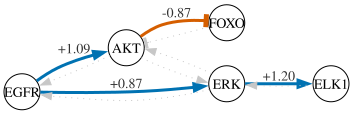

In [8]:
edge_styles = {}
for edge_index, row in edge_table.iterrows():
    if row["selected"]:
        edge_styles[edge_index] = {
            "color": "#D55E00" if row["coefficient"] < 0 else "#0072B2",
            "fontcolor": "#333333",
            "label": f'{row["coefficient"]:+.2f}',
            "penwidth": "3",
        }
    else:
        edge_styles[edge_index] = {
            "color": "#C7C7C7",
            "style": "dotted",
        }

pkn.plot(custom_edge_attr=edge_styles, graph_attr={"rankdir": "LR"})

(linear-dag-edge-metadata)=
### Inspect fitted edge metadata

`get_solution_graph()` makes the interpretation explicit. It preserves a prior interaction sign as `prior_interaction`, records the fitted sign as `inferred_interaction`, and marks structural-only zero-coefficient edges as `connector`. In exact mode, connectors should be absent because selected edges must have a nonzero normalized coefficient.

In [9]:
solution_graph = method.get_solution_graph()
solution_rows = []
for edge_index, (source_set, target_set) in enumerate(solution_graph.E):
    attributes = solution_graph.get_attr_edge(edge_index)
    solution_rows.append(
        {
            "source": next(iter(source_set)),
            "target": next(iter(target_set)),
            "coefficient": attributes["coefficient"],
            "normalized_coefficient": attributes["normalized_coefficient"],
            "prior_interaction": attributes.get("prior_interaction"),
            "inferred_interaction": attributes["inferred_interaction"],
            "connector": attributes["connector"],
        }
    )
pd.DataFrame(solution_rows)

,source,target,coefficient,normalized_coefficient,prior_interaction,inferred_interaction,connector
0,EGFR,AKT,1.086810,0.910399,1,1,False
1,EGFR,ERK,0.866341,0.849813,1,1,False
2,AKT,FOXO,-0.865437,-0.975949,-1,-1,False
3,ERK,ELK1,1.195922,0.956738,1,1,False


At these parameter values, the optimizer selects the four interactions used to generate the synthetic data. Their coefficients are close to, but not exactly, the generating values $1.1$, $0.8$, $-0.9$, and $1.2$. The available reverse edges, feedback edges, and AKT–ERK cross-talk are not selected in this fit; that result does not establish that such interactions are absent in real biology. The selected graph has no directed cycles even though the PKN contains them.

(linear-dag-prediction)=
## Reuse the fitted model for held-out prediction

The example above calls `build()` and `solve()` separately. Use that form when you need to add constraints to the optimization problem before solving it. If you do not need custom constraints, `fit()` performs those two steps and returns the fitted `LinearDAGDiscovery` object.

| Operation | Values used from the new data | Meaning |
|---|---|---|
| `predict(data)` | Hard-intervention target values and explicit or previously fitted shift interventions | Applies the fixed selected graph recursively. It does not solve again and does not use ordinary observed values as inputs. |
| `evaluate(data)` forward loss | The predictions above, followed by the observed values used only for scoring | Measures recursive forward prediction error without feeding observed descendants into the model. Every observed vertex that is not hard-intervened is scored, including roots. |
| `evaluate(data)` local loss | Observed target and observed values for every incoming PKN parent | Measures how well each fitted equation reconstructs its target when its parent measurements are supplied. This is a diagnostic, not an independent forward prediction. |
| `residuals(data)` | The same observed-parent calculation as local loss | Returns `observed target − equation reconstruction` for each usable target and sample. |

A **root** is a vertex with no selected incoming edge. `predict()` uses its fitted intercept, not an ordinary observed value. This example sets `fit_intercept=False`, so a root that is not hard-intervened is predicted as zero. In the held-out `ERK_on` row, ERK is fixed by the intervention but EGFR is not; the observed EGFR value is therefore ignored as an input and its prediction is zero. Because `evaluate()` scores observed non-hard vertices, the EGFR error contributes to `forward_loss`. If a root value is an externally supplied input rather than an outcome to predict, mark it as a hard intervention; `predict()` will then fix it to the supplied value and `evaluate()` will exclude that target from the loss.

The reported losses are weighted means after dividing errors by the response scales learned from the training data; they are not the raw summed optimization objective. Configured `vertex_weights` apply. Evaluation `sample_weights` must be supplied using the held-out sample names—training weights are not automatically transferred to different samples. Select penalties and other model settings using training or validation data, not the final test report. Holding out replicate cells tests prediction for new cells under familiar interventions; holding out an entire condition tests prediction for an intervention condition not used in fitting.

In [10]:
# Hold out one complete hard-intervention condition while retaining the
# observational and other intervention conditions for training.
heldout_name = "ERK_on"
train_data = data.query.filter(lambda item: item[0] != heldout_name).collect()
test_data = data.query.filter(lambda item: item[0] == heldout_name).collect()

heldout_model = LinearDAGDiscovery(
    lambda_edges=0.1,
    coefficient_bound=3.0,
    fit_intercept=False,
    max_parents=2,
    enforce_signs=True,
    coefficient_support="exact",
    min_abs_coefficient=0.25,
).fit(pkn, train_data, solve_options={"solver": "SCIPY"})

predictions = heldout_model.predict(test_data)
report = heldout_model.evaluate(test_data)
pd.DataFrame(
    {
        "forward_loss": report["forward_by_condition"],
        "local_loss": report["local_by_condition"],
    }
).round(3)

,forward_loss,local_loss
ERK_on,0.473,0.232


In [11]:
# Prediction Data keeps sample/vertex labels and identifies clamped values.
pd.DataFrame(
    [feature.to_dict() for feature in predictions.samples[heldout_name].features]
).set_index("id")[["value", "predicted", "clamped", "observed"]].loc[["ERK", "ELK1"]]

,value,predicted,clamped,observed
id,,,,
ERK,1.700000,False,True,True
ELK1,2.033068,True,False,True


Prediction and residual results retain their sample and vertex labels. Their feature metadata states exactly how each value was produced:

| Metadata | Meaning |
|---|---|
| `predicted` | The value was produced by the fixed forward model |
| `clamped` | The value was fixed to a supplied hard-intervention value rather than predicted |
| `observed` | The input data contained a value. `predict()` ignores it unless it belongs to a hard intervention; `evaluate()` may use it as the value to score. |
| `valid` | The target and every required parent were observed, so the local residual can be computed |
| `equation_prediction` | The target value reconstructed from its observed parents for the local residual |

For a shift intervention, the target measurement may be missing when the shift value is supplied explicitly. A shift estimated during fitting can be reused only for the same `intervention_group`. A numeric shift supplied in the training data is not memorized for later samples; supply it again at prediction time. For a new group, also supply the shift explicitly because test outcomes are never used to estimate it.

## Inspect the in-sample equation reconstructions

This plot is an in-sample fitting diagnostic, not a held-out prediction test. For each target, `problem.expr.prediction` substitutes the observed parent measurements into that target's fitted equation. A point near the diagonal therefore shows that one equation reconstructs its observed target; it does not show that the complete graph can predict the sample without those parent measurements.

The plot includes only vertices with at least one selected incoming edge and only rows marked by `fitted_mask`. A hard-intervention target, a missing target, or a target with any missing candidate parent is excluded. The table reports mean absolute reconstruction error in the original measurement units.

EGFR is omitted because it has no selected incoming edge. In this example, `fit_intercept=False` makes its non-hard equation simply `EGFR = 0`; those residuals are constant with respect to edge selection and are not informative about downstream fit.

,fitted observations,mean absolute error
protein,,
AKT,8,0.073
ERK,7,0.059
FOXO,10,0.080
ELK1,9,0.039


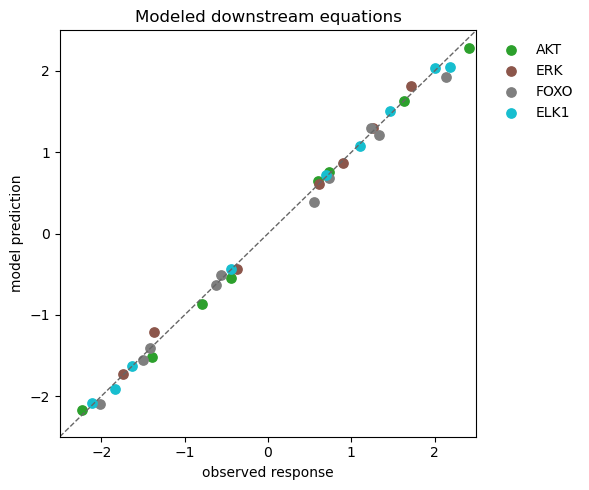

In [12]:
prediction = np.asarray(problem.expr.prediction.value)
fitted_mask = np.asarray(problem.expr.fitted_mask.value).astype(bool)
modeled_vertices = set(edge_table.loc[selected, "target"])

fig, ax = plt.subplots(figsize=(6, 5))
colors = plt.cm.tab10(np.linspace(0, 1, pkn.num_vertices))
fit_summary = []
for vertex_index, vertex in enumerate(pkn.V):
    if vertex not in modeled_vertices:
        continue
    keep = fitted_mask[vertex_index]
    observed = np.full(len(data.samples), np.nan)
    for sample_index, sample_name in enumerate(data.samples):
        feature = next((feature for feature in data.samples[sample_name].features if feature.id == vertex), None)
        if feature is not None and feature.value is not None:
            observed[sample_index] = float(feature.value)
    observed = observed[keep]
    modeled = prediction[vertex_index, keep]
    ax.scatter(
        observed,
        modeled,
        label=vertex,
        color=colors[vertex_index],
        s=45,
    )
    fit_summary.append(
        {
            "protein": vertex,
            "fitted observations": int(keep.sum()),
            "mean absolute error": np.mean(np.abs(observed - modeled)),
        }
    )
limits = [-2.5, 2.5]
ax.plot(limits, limits, "--", color="0.4", linewidth=1)
ax.set(xlabel="observed response", ylabel="model prediction", xlim=limits, ylim=limits)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_title("Modeled downstream equations")
fig.tight_layout()

pd.DataFrame(fit_summary).set_index("protein").round(3)

## Check what was actually fitted

This table shows which values enter the fitting loss. `observed_mask` is true whenever a measurement is present. `fitted_mask` is more restrictive: it is false for hard-intervention targets and whenever the target or any of its candidate parents is missing. Here a **candidate parent** means any vertex with an incoming PKN edge to the target, even when that edge is not selected.

Consequently, one missing candidate-parent value can remove a target equation from that sample. This uses fewer observations than a workflow that first fills in missing values, but it guarantees that CORNETO never silently replaces a missing parent with zero.

In [13]:
observed_mask = pd.DataFrame(
    np.asarray(problem.expr.observed_mask.value).astype(bool).T,
    index=tuple(data.samples),
    columns=pkn.V,
)
used_for_fit = pd.DataFrame(
    fitted_mask.T,
    index=tuple(data.samples),
    columns=pkn.V,
)

pd.concat(
    {"observed": observed_mask, "used in loss": used_for_fit},
    axis=1,
)

observed                          used in loss                      \
              EGFR   AKT   ERK  FOXO   ELK1         EGFR    AKT    ERK  FOXO   
obs_1         True  True  True  True   True         True   True   True  True   
obs_2         True  True  True  True   True         True   True   True  True   
obs_3         True  True  True  True   True         True   True   True  True   
obs_4         True  True  True  True   True         True   True   True  True   
EGFR_low      True  True  True  True   True        False   True   True  True   
EGFR_high     True  True  True  True   True        False   True   True  True   
AKT_on        True  True  True  True  False         True  False  False  True   
AKT_off       True  True  True  True   True         True  False   True  True   
ERK_on        True  True  True  True   True         True   True  False  True   
ERK_off       True  True  True  True   True         True   True  False  True   

                  
            ELK1  
obs_1       True  
obs_2       True  
obs_3       True  
obs_4       True  
EGFR_low    True  
EGFR_high   True  
AKT_on     False  
AKT_off     True  
ERK_on      True  
ERK_off     True

## Adapting the workflow to your experiment

For a real perturbation panel:

1. use centered continuous measurements, such as log-fold changes relative to an appropriate control;
2. map every feature identifier to the same identifiers used by the PKN;
3. annotate the intervened target feature using the metadata described above;
4. represent missing measurements as absent features, `None`, or `NaN`;
5. inspect `fitted_mask`, then rerun plausible `lambda_edges` and `min_abs_coefficient` values and report which edges change.

Optional weights can reflect assay reliability or unequal sample importance:

```python
method = LinearDAGDiscovery(
    vertex_weights={"FOXO": 0.5},       # noisier readout
    sample_weights={"replicate_3": 0.7},
)
```

Weights must be positive and multiply the corresponding contribution to the fitting loss. Standardization can be disabled with `standardize_loss=False`; leave it enabled when errors should be judged relative to each target's observed training variation, and disable it when the raw measurement scale itself should determine their relative importance.

With exact coefficient support, `min_abs_coefficient` applies to `coefficient × source_scale / target_scale`, not to the displayed raw coefficient. With structural support, a selected edge may instead have coefficient zero and serve only to complete a connectivity route.

## Advanced options and formulation

The sections below are useful when tuning the method or diagnosing a difficult dataset; they are not required for the basic workflow.

(linear-dag-model-choices)=
### Model choices and their exact effects

| Parameter | Effect |
|---|---|
| `lambda_edges` | Adds this amount to the objective for every selected edge. Increasing it trades more fitting error for fewer selected edges. |
| `max_parents` | Maximum number of selected incoming edges allowed at each vertex. An integer applies to every vertex; a mapping can set vertex-specific limits. |
| `enforce_signs` | When true, a PKN sign of `+1` requires a nonnegative coefficient and `-1` requires a nonpositive coefficient. |
| `coefficient_support` | `exact` requires every selected edge to have a sufficiently large nonzero coefficient; `structural` allows a selected connectivity edge to have coefficient zero. |
| `min_abs_coefficient` | In exact mode, the minimum of `abs(coefficient × source_scale / target_scale)` for a selected edge. |
| `min_commodity_coverage` | Minimum fraction of intervention evidence units whose shared flow column must contain a complete route to at least one measured, non-intervened response. |
| `lambda_unexplained` | Adds a penalty for evidence units whose shared flow column has no complete route; unlike the minimum above, it does not make that coverage mandatory. |
| `loss="absolute"` | Default: minimizes absolute standardized errors, which reduces the influence of individual large errors. |
| `loss="squared"` | Minimizes squared standardized errors, so large errors receive much more weight. This also changes the problem from a mixed-integer linear program to a mixed-integer quadratic program. |

`flow_epsilon` and `flow_capacity` are technical bounds for the auxiliary connectivity variables, not descriptions of biology. `flow_epsilon` is the smallest positive value assigned to an edge used by a flow; `flow_capacity` is its upper bound. The default capacity is the number of PKN edges multiplied by `flow_epsilon`. Normally these values should not be used to express biological confidence or effect size.

For a real analysis, solve several scientifically plausible edge penalties and coefficient thresholds and report which edges remain selected. One optimized graph is not an uncertainty estimate.

### What does `min_commodity_coverage` mean?

The parameter retains the internal term *commodity* from flow problems, but it controls intervention-to-response connectivity. Three levels must be distinguished:

| Level | Exact meaning |
|---|---|
| Sample | One row in `Data`, such as one cell or one bulk condition. Every sample remains a separate regression observation. |
| Evidence unit | One explicit `(intervened source, intervention_group)` pair. Replicate cells in that group count as one unit. Samples without a group are pooled into one implicit unit when they have the same flow pattern. |
| Flow column | One auxiliary connectivity problem for a unique pattern: the intervened source, the measured non-intervened responses available as endpoints, and the edges blocked by hard interventions. |

Several explicit evidence units can have the same pattern and therefore share one flow column. They are counted separately through that column's `group_count`, but they cannot receive different coverage decisions: when the shared flow is active, all those units count as covered; when it is inactive, none do. Ungrouped samples with the same pattern are pooled into one implicit evidence unit and therefore count once.

An evidence unit counts as covered when its shared flow column contains a directed route from the intervened source to at least one measured response that is not itself intervened, using at least one selected PKN edge. This says only that the route exists. It does not use prediction error or require a route to every response.

If there are ten evidence units:

- `min_commodity_coverage=0` does not require any evidence unit to be connected;
- `min_commodity_coverage=0.6` requires shared active flow columns representing at least `ceil(0.6 × 10) = 6` evidence units;
- `min_commodity_coverage=1` requires flow columns representing all ten evidence units and makes the problem infeasible if the PKN cannot provide every required route.

Coverage is only a graph-connectivity requirement. A covered unit may still be predicted poorly, and coverage is not a significance test or confidence score. Use `1` only when every evidence unit should have a route to at least one measured downstream vertex in the PKN. Otherwise leave the minimum at zero, choose a smaller fraction, or use `lambda_unexplained` to penalize missing routes without making them mandatory.

## Method details

### Linear structural equations

For every usable measurement whose target is not hard-intervened, the fitted equation for vertex $v$ in sample $s$ is

$$
\hat{x}_{v,s} = \alpha_v + \sum_{u\to v} \beta_{u\to v}x_{u,s} + d_{v,s}.
$$

Here $\alpha_v$ is the optional intercept, $\beta_{u\to v}$ is the fitted edge coefficient, and $d_{v,s}$ is zero unless that target has a shift intervention. A shift can be supplied numerically or estimated from an `intervention_group`. An unselected edge has coefficient zero. A hard-intervention target has no fitted equation in that sample; its supplied value can still appear as a parent value in downstream equations.

With the default absolute-error loss and no optional shift or coverage penalties, the objective is

$$
\sum_{(v,s)\,\mathrm{fitted}}
\frac{w_v w_s}{\sigma_v}\left|x_{v,s}-\hat{x}_{v,s}\right|
+ \lambda_E\sum_e z_e.
$$

In this expression, $w_v$ and $w_s$ are the optional vertex and sample weights, $\sigma_v$ is the training-derived response scale, and $z_e$ is 1 when edge $e$ is selected. The target scale is computed from observations where the target is not hard-intervened and every candidate parent is present. A missing parent is never replaced with zero.

In exact coefficient-support mode, selecting edge $e:u\to v$ also requires $|\tilde{\beta}_e|\ge\delta$, where $\tilde{\beta}_e=\beta_e\,\mathrm{scale}(u)/\mathrm{scale}(v)$ and $\delta$ is `min_abs_coefficient`.

During fitting and local residual calculation, $x_{u,s}$ is the observed parent value. During forward prediction, it is the model's previously predicted parent value. Ordinary observed values in the new data—including observed roots—are not substituted into the forward calculation. A hard-intervention target is fixed to its supplied value, and a root that is not hard-intervened uses only its fitted intercept.

### Relationship to SEMs and SCMs

A structural equation model (SEM) describes each variable using an equation based on its parent variables. In a linear SEM, the equation for vertex $v$ is

$$
X_v = \alpha_v + \sum_{u\in\mathrm{Pa}(v)} \beta_{uv}X_u + \varepsilon_v.
$$

Here, $\mathrm{Pa}(v)$ is the set of parents of $v$, $\alpha_v$ is its baseline value, $\beta_{uv}$ is the coefficient for the edge $u\rightarrow v$, and $\varepsilon_v$ represents variation not explained by the modeled parents. An SEM is not necessarily causal: the equations may describe statistical relationships without claiming what would happen if a variable were manipulated.

A structural causal model (SCM) gives the equations a causal interpretation. Each equation is treated as the mechanism that produces its variable. An intervention replaces or modifies one mechanism while the remaining equations stay unchanged. For example, a hard intervention $\operatorname{do}(X_v=x)$ replaces the equation for $X_v$ with the fixed value $x$.

`LinearDAGDiscovery` selects the parent relationships from the candidate edges in the PKN and estimates their linear coefficients. It therefore fits a PKN-constrained linear SEM. Hard interventions fix the target and remove its usual equation for that sample, while shift interventions add an offset to the equation. Under suitable causal assumptions, these intervention semantics allow the fitted model to be interpreted as a linear acyclic SCM.

| Result | What it contains | Causal interpretation | Interventions |
|---|---|---|---|
| Directed graph or DAG | Variables and directed edges | Not established by the graph alone | Not defined by the graph alone |
| Linear SEM | Graph, linear equations, coefficients, and unexplained variation | Optional; equations may be statistical | Not defined unless causal meaning is added |
| Linear SCM | Linear equations interpreted as causal mechanisms | Yes, by assumption | Replace or modify the target equation |
| `LinearDAGDiscovery` | A DAG selected from the PKN, fitted linear equations, and intervention annotations | Valid when the PKN, intervention design, absence of important hidden common causes, and mechanism stability assumptions are appropriate | Hard interventions replace the target equation; shift interventions modify it |

The optimization cannot verify the assumptions required for the SCM interpretation. Without them, the result should be treated as an intervention-aware linear SEM rather than proof of a causal model. CORNETO's auxiliary flows are not part of the SEM or SCM; they only restrict graph selection by requiring selected edges to participate in intervention-to-measurement routes.

### How the connectivity constraints work

For each unique flow pattern described above, CORNETO creates auxiliary variables that must obey these rules:

1. flow enters at that pattern's intervened source;
2. it can leave only through responses measured and not intervened in the corresponding samples;
3. it can use only selected PKN edges;
4. every selected PKN edge must be used by at least one flow column; and
5. an incoming edge to a hard-intervention target is unavailable in that flow column, although it remains available in other intervention patterns and in the regression equations where applicable.

These rules ensure that selected edges form intervention-to-measurement routes rather than disconnected graph fragments. By default, `min_commodity_coverage=0`, so a particular flow column may remain inactive. When coverage or unexplained-route penalties are enabled, each flow column is weighted by the number of evidence units it represents (`group_count`), including explicit groups and any pooled implicit unit. The table below shows which auxiliary flow columns use each selected edge.

In [14]:
usage = method.get_edge_usage()
commodity_labels = []
for info in method.get_commodity_info():
    evidence = [
        f"{unit['intervention_group'] or 'implicit'}: {', '.join(map(str, unit['sample_names']))}"
        for unit in info['evidence_units']
    ]
    commodity_labels.append(f"flow {info['index']}: do({info['source']}) [{'; '.join(evidence)}]")
selected_labels = [
    f'{row.source} → {row.target}'
    for row in edge_table.loc[selected].itertuples()
]

pd.DataFrame(
    usage[selected].astype(int),
    index=selected_labels,
    columns=commodity_labels,
)

,"flow 0: do(EGFR) [implicit: EGFR_low, EGFR_high]",flow 1: do(AKT) [implicit: AKT_on],flow 2: do(AKT) [implicit: AKT_off],"flow 3: do(ERK) [implicit: ERK_on, ERK_off]"
EGFR → AKT,1,0,0,0
EGFR → ERK,1,0,0,0
AKT → FOXO,1,0,0,0
ERK → ELK1,1,0,0,0


A `1` means that the auxiliary connectivity route uses that edge. It does **not** measure signaling strength, confidence, molecule abundance, or causal effect size. The fitted coefficient—not the flow value—determines how an edge contributes to a linear equation.

## Interpretation and limitations

The result is one acyclic linear model minimizing the configured combination of fitting error, edge penalty, and any enabled intervention-shift or missing-route penalties. It is not necessarily the graph with the fewest edges. A time-limited solver result may be only the best feasible graph found before the limit, rather than a proven optimum.

With exact coefficient support, every selected edge has a normalized coefficient at least as large as the chosen threshold. With structural support, an edge may be selected only to complete a connectivity route and still have coefficient zero. Neither choice guarantees a nonzero total effect from an intervention to a response: effects along different paths can cancel.

Its interpretation depends on several assumptions:

- coefficients can be learned only from samples containing the required target and parent measurements; a fully unobserved internal vertex has no data from which to estimate its equation;
- coefficients are shared across conditions and effects are additive and linear;
- `intervention="hard"` fixes the target and removes its equation for that sample;
- hidden common causes, feedback dynamics, and condition-specific coefficients are not modeled;
- an edge can be selected only if at least one auxiliary intervention-to-response route uses it, even if an excluded edge is biologically real;
- alternative graphs may fit noisy data similarly.

Before drawing conclusions, repeat the analysis across plausible edge penalties and coefficient thresholds, resample conditions or cells where appropriate, and test reasonable PKN variants. Report which interactions remain selected and which alternative graphs explain the data similarly.
